In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
data_penduduk = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Data%20Penduduk.csv", sep=";")
display(data_penduduk.iloc[0:])

,Daerah,Kecamatan,Jumlah_Penduduk,Total
0,Kabupaten_Jombang,Bandar Kedung Mulyo,52584.0,1370000.0
1,NaN,Perak,59075.0,NaN
2,NaN,Gudo,58800.0,NaN
3,NaN,Diwek,113978.0,NaN
4,NaN,Ngoro,80318.0,NaN
...,...,...,...,...
88,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN
90,NaN,NaN,NaN,NaN
91,NaN,NaN,NaN,NaN


In [ ]:
data_penduduk = data_penduduk.dropna(subset=["Kecamatan", "Jumlah_Penduduk"])
data_penduduk = data_penduduk.ffill()
display(data_penduduk.iloc[0:])
# data.to_csv("Data Penduduk (Olahan).csv", index=False)

,Daerah,Kecamatan,Jumlah_Penduduk,Total
0,Kabupaten_Jombang,Bandar Kedung Mulyo,52584.0,1370000.0
1,Kabupaten_Jombang,Perak,59075.0,1370000.0
2,Kabupaten_Jombang,Gudo,58800.0,1370000.0
3,Kabupaten_Jombang,Diwek,113978.0,1370000.0
4,Kabupaten_Jombang,Ngoro,80318.0,1370000.0
...,...,...,...,...
83,Kota_Surabaya,Bubutan,96700.0,3017800.0
84,Kota_Surabaya,Krembangan,114900.0,3017800.0
85,Kota_Surabaya,Asemrowo,48800.0,3017800.0
86,Kota_Surabaya,Benowo,74900.0,3017800.0


In [ ]:
data_halte_kor2 = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Halte_Koridor2_TransJatim.csv", sep=";")
data_rute_kor2 = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Rute_Koridor2_TransJatim.csv", sep=";")
data_halte_kor6 = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Halte_Koridor6_TransJatim.csv", sep=";")
data_rute_kor6 = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Rute_Koridor6_TransJatim.csv", sep=";")

display(data_halte_kor2.iloc[0:])
display(data_rute_kor2.iloc[0:])
display(data_halte_kor6.iloc[0:])
display(data_rute_kor6.iloc[0:])

,Kode_Halte,Nama_Halte,Latitude,Longitude,Koridor
0,H02_01,Dukuh_Menanggal,-7.343450,112.728877,2
1,H02_02,Siwalankerto2,-7.336929,112.729541,2
2,H02_03,Medaeng,-7.350101,112.713174,2
3,H02_04,Kemendung2,-7.370128,112.651001,2
4,H02_05,Trosobo_Pos2,-7.375425,112.636149,2
5,H02_06,Bypass_Timur2,-7.389095,112.606860,2
6,H02_07,Terminal_Krian,-7.411490,112.582921,2
7,H02_08,Klenteng_Krian,-7.411127,112.577341,2
8,H02_09,Jabaran2,-7.414344,112.554602,2
9,H02_10,Bypass_Barat2,-7.414805,112.546892,2


,From_Halte,To_Halte,Jarak_km,Koridor
0,H02_01,H02_02,2.70,2
1,H02_02,H02_03,3.20,2
2,H02_03,H02_04,7.40,2
3,H02_04,H02_05,1.80,2
4,H02_05,H02_06,3.60,2
5,H02_06,H02_07,4.20,2
6,H02_07,H02_08,1.00,2
7,H02_08,H02_09,2.60,2
8,H02_09,H02_10,0.85,2
9,H02_10,H02_11,1.80,2


,Kode_Halte,Nama_Halte,Latitude,Longitude,Koridor
0,H06_01,Terminal_Porong,-7.538896,112.696045,6
1,H06_02,Shelter_Arteri_Porong,-7.539237,112.685131,6
2,H06_03,Rambu_Gempol1,-7.554312,112.695062,6
3,H06_04,Rambu_Apollo,-7.578530,112.690884,6
4,H06_05,Rambu_Japanan1,-7.564041,112.690757,6
5,H06_06,Rambu_Carat1,-7.562219,112.682401,6
6,H06_07,Shelter_Nglawang1,-7.568441,112.674010,6
7,H06_08,Shelter_PUSDIK_BRIMOB1,-7.566713,112.658000,6
8,H06_09,Rambu_Watesnegoro1,-7.564237,112.647659,6
9,H06_10,Shelter_Manduro1,-7.562584,112.640379,6


,From_Halte,To_Halte,Jarak_km,Koridor
0,H06_01,H06_02,1.40,6
1,H06_02,H06_03,2.50,6
2,H06_03,H06_04,3.20,6
3,H06_04,H06_05,1.80,6
4,H06_05,H06_06,0.95,6
5,H06_06,H06_07,1.30,6
6,H06_07,H06_08,1.80,6
7,H06_08,H06_09,1.20,6
8,H06_09,H06_10,0.85,6
9,H06_10,H06_11,0.90,6


In [ ]:
data_waypoints = pd.read_csv("https://raw.githubusercontent.com/adriann03/dataset_mahasiswa_matdis_a/refs/heads/main/Waypoints.csv", sep=";")
display(data_waypoints.iloc[0:])

,Titik Penting,Latitude,Longitude
0,Terminal_Kertajaya,-7.491291,112.448998
1,Waterland,-7.514893,112.423065
2,Puskesmas Sooko,-7.527181,112.412264
3,Pertamina,-7.539036,112.391925
4,Seberang_Taman_Mojoagung,-7.570624,112.344821
5,Seberang_Puskesmas_Jogoloyo,-7.555839,112.305571
6,Indomaret_Fresh_Janti,-7.552380,112.299411
7,RTH_Keplaksari,-7.537623,112.262793
8,Stasiun_Jombang,-7.557709,112.233746
9,Taman_Kota_Ringin_Contong,-7.538427,112.237961


Mengumpulkan seluruh halte lintas koridor

In [ ]:
all_haltestops = pd.concat([data_halte_kor2, data_halte_kor6], ignore_index=True)
print("First 5 rows of all_haltestops:")
display(all_haltestops.head())

print("Data types of all_haltestops columns:")
display(all_haltestops.info())

First 5 rows of all_haltestops:


,Kode_Halte,Nama_Halte,Latitude,Longitude,Koridor
0,H02_01,Dukuh_Menanggal,-7.343450,112.728877,2
1,H02_02,Siwalankerto2,-7.336929,112.729541,2
2,H02_03,Medaeng,-7.350101,112.713174,2
3,H02_04,Kemendung2,-7.370128,112.651001,2
4,H02_05,Trosobo_Pos2,-7.375425,112.636149,2


Data types of all_haltestops columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Kode_Halte  50 non-null     object 
 1   Nama_Halte  50 non-null     object 
 2   Latitude    50 non-null     float64
 3   Longitude   50 non-null     float64
 4   Koridor     50 non-null     int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 2.1+ KB


None

**Reasoning**:
To verify the structure and data types of the `all_routes` DataFrame, I will display its first five rows and then check the data types of all its columns, specifically focusing on 'From_Halte' and 'To_Halte'.



In [ ]:
all_routes = pd.concat([data_rute_kor2, data_rute_kor6], ignore_index=True)
print("First 5 rows of all_routes:")
display(all_routes.head())

print("Data types of all_routes columns:")
display(all_routes.info())

First 5 rows of all_routes:


,From_Halte,To_Halte,Jarak_km,Koridor
0,H02_01,H02_02,2.7,2
1,H02_02,H02_03,3.2,2
2,H02_03,H02_04,7.4,2
3,H02_04,H02_05,1.8,2
4,H02_05,H02_06,3.6,2


Data types of all_routes columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   From_Halte  48 non-null     object 
 1   To_Halte    48 non-null     object 
 2   Jarak_km    48 non-null     float64
 3   Koridor     48 non-null     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 1.6+ KB


None

## Visualize Bus Network

### Subtask:
Hasilkan peta interaktif menggunakan folium untuk memvisualisasikan semua halte bus berdasarkan garis lintang dan garis bujurnya, dan gambar garis yang menghubungkannya sesuai dengan rute yang ditentukan dalam all_routes, dengan jelas membedakan antara koridor yang berbeda jika berlaku.


**Reasoning**:
To visualize the bus network as an interactive map, I need to import the `folium` library, calculate the map's center, define a color scheme for the corridors, then iterate through the bus stops to add markers and through the routes to draw lines, all with popups for detailed information, and finally display the map as per the subtask instructions.



In [ ]:
import folium

# Calculate the average latitude and longitude for map centering
center_lat = all_haltestops['Latitude'].mean()
center_lon = all_haltestops['Longitude'].mean()

# Create a folium map object
bus_map = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Define a color scheme for different corridors
corridor_colors = {
    2: 'blue',  # Koridor 2
    6: 'red',    # Koridor 6
    waypoints: '#06c200' # waypoints
}

# Add bus stop markers to the map
for index, row in all_haltestops.iterrows():
    koridor_color = corridor_colors.get(row['Koridor'], 'green') # Default to green if corridor not in dict
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=koridor_color,
        fill=True,
        fill_color=koridor_color,
        fill_opacity=0.7,
        popup=f"<b>Halte:</b> {row['Nama_Halte']}<br><b>Koridor:</b> {row['Koridor']}"
    ).add_to(bus_map)

# Prepare DataFrame for route coordinates lookup
halte_coords = all_haltestops.set_index('Kode_Halte')

# Add routes (polylines) to the map
for index, row in all_routes.iterrows():
    from_halte_code = row['From_Halte']
    to_halte_code = row['To_Halte']
    koridor_id = row['Koridor']

    try:
        from_lat = halte_coords.loc[from_halte_code, 'Latitude']
        from_lon = halte_coords.loc[from_halte_code, 'Longitude']
        to_lat = halte_coords.loc[to_halte_code, 'Latitude']
        to_lon = halte_coords.loc[to_halte_code, 'Longitude']

        route_color = corridor_colors.get(koridor_id, 'black') # Default to black for routes

        folium.PolyLine(
            locations=[[from_lat, from_lon], [to_lat, to_lon]],
            color=route_color,
            weight=3,
            opacity=0.7,
            popup=f"<b>From:</b> {from_halte_code}<br><b>To:</b> {to_halte_code}<br><b>Koridor:</b> {koridor_id}<br><b>Jarak (km):</b> {row['Jarak_km']}"
        ).add_to(bus_map)
    except KeyError as e:
        print(f"Warning: Could not find coordinates for halte code {e}. Skipping route.")

# Display the map
bus_map

## Analisis Sebaran Populasi


In [ ]:
#periksa missing values
#harusnya sudah tidak ada
display(data_penduduk.info())

<class 'pandas.core.frame.DataFrame'>
Index: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Daerah           88 non-null     object 
 1   Kecamatan        88 non-null     object 
 2   Jumlah_Penduduk  88 non-null     float64
 3   Total            88 non-null     float64
dtypes: float64(2), object(2)
memory usage: 3.4+ KB


None

In [ ]:
print("Statistika Deskriptif jumlah penduduk")
display(data_penduduk[['Jumlah_Penduduk']].describe())

Statistika Deskriptif jumlah penduduk


,Jumlah_Penduduk
count,88.000000
mean,87578.409091
std,45216.805667
min,23759.000000
25%,58675.000000
50%,75915.000000
75%,100466.000000
max,227000.000000


**Reasoning**:
To identify densely populated areas, I will group the `data_penduduk` DataFrame by 'Kecamatan', sum the 'Jumlah_Penduduk' for each district, and then display the districts with the highest populations, as per the instructions.



In [ ]:
print("Kecamatan dengan populasi terbanyak:")
populasi_per_kecamatan = data_penduduk.groupby('Kecamatan')['Jumlah_Penduduk'].sum().sort_values(ascending=False)
display(populasi_per_kecamatan.head(10))

Kecamatan dengan populasi terbanyak:


,Jumlah_Penduduk
Kecamatan,
Tambaksari,227000.0
Taman,217900.0
Sidoarjo,215073.0
Waru,211050.0
Sawahan,198500.0
Kenjeran,185300.0
Semampir,183300.0
Candi,167340.0
Ngoro,165918.0


In [ ]:
populasi_per_daerah = data_penduduk.drop_duplicates(subset=["Daerah"])
populasi_per_daerah = populasi_per_daerah.drop(["Kecamatan", "Jumlah_Penduduk"], axis="columns")
display(populasi_per_daerah)
display(populasi_per_daerah.describe())

,Daerah,Total
0,Kabupaten_Jombang,1370000.0
21,Kabupaten_Sidoarjo,2171500.0
39,Kabupaten_Mojokerto,1147600.0
57,Kota_Surabaya,3017800.0


,Total
count,4.000000e+00
mean,1.926725e+06
std,8.499682e+05
min,1.147600e+06
25%,1.314400e+06
50%,1.770750e+06
75%,2.383075e+06
max,3.017800e+06


## Graf Rute Bis


In [ ]:
G = nx.DiGraph() #graf berarah

for index, row in all_haltestops.iterrows():
    G.add_node(row['Kode_Halte'], name=row['Nama_Halte'], latitude=row['Latitude'], longitude=row['Longitude'], koridor=row['Koridor'])

for index, row in all_routes.iterrows():
    G.add_edge(row['From_Halte'], row['To_Halte'], weight=row['Jarak_km'], koridor=row['Koridor'])

print(f"Graf denagn {G.number_of_nodes()} node dan {G.number_of_edges()} edge.")
print("Data node:", list(G.nodes(data=True))[:5])
print("Data edge:", list(G.edges(data=True))[:5])

Graf denagn 50 node dan 48 edge.
Data node: [('H02_01', {'name': 'Dukuh_Menanggal', 'latitude': -7.34345, 'longitude': 112.728877, 'koridor': 2}), ('H02_02', {'name': 'Siwalankerto2', 'latitude': -7.336929, 'longitude': 112.729541, 'koridor': 2}), ('H02_03', {'name': 'Medaeng', 'latitude': -7.350101, 'longitude': 112.713174, 'koridor': 2}), ('H02_04', {'name': 'Kemendung2', 'latitude': -7.370128, 'longitude': 112.651001, 'koridor': 2}), ('H02_05', {'name': 'Trosobo_Pos2', 'latitude': -7.375425, 'longitude': 112.636149, 'koridor': 2})]
Data edge: [('H02_01', 'H02_02', {'weight': 2.7, 'koridor': 2}), ('H02_02', 'H02_03', {'weight': 3.2, 'koridor': 2}), ('H02_03', 'H02_04', {'weight': 7.4, 'koridor': 2}), ('H02_04', 'H02_05', {'weight': 1.8, 'koridor': 2}), ('H02_05', 'H02_06', {'weight': 3.6, 'koridor': 2})]


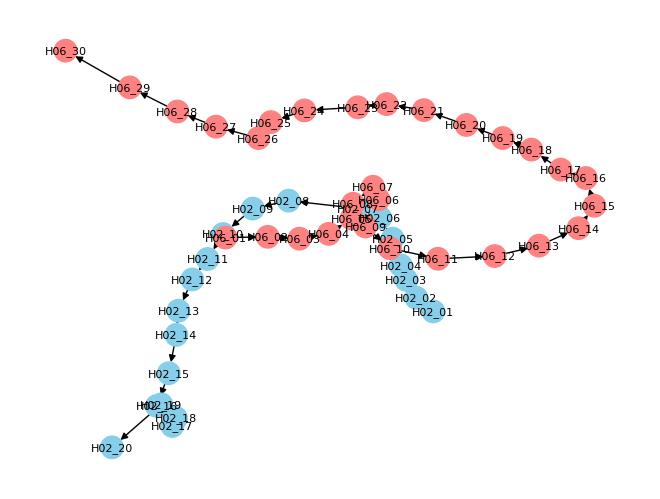

In [ ]:
node_colors_list = ["#ff8282" if "H06" in n else 'skyblue'for n in G.nodes()]
nx.draw(G, with_labels=True, node_size=260, node_color=node_colors_list, font_size=8)

## Analyze Graph Connectivity

### Subtask:
Assess the connectivity of the bus network by checking if the graph is strongly connected or weakly connected. Also, determine the number of connected components to understand network fragmentation.


**Reasoning**:
To assess the graph connectivity as per the instructions, I will use networkx functions to check for strong and weak connectivity and calculate the number of strongly and weakly connected components.



In [ ]:
print("Checking graph connectivity:")

# Check if the graph is strongly connected
is_strongly_connected = nx.is_strongly_connected(G)
print(f"Is the graph strongly connected? {is_strongly_connected}")

# Check if the graph is weakly connected
is_weakly_connected = nx.is_weakly_connected(G)
print(f"Is the graph weakly connected? {is_weakly_connected}")

# Calculate the number of strongly connected components
num_strongly_connected_components = nx.number_strongly_connected_components(G)
print(f"Number of strongly connected components: {num_strongly_connected_components}")

# Calculate the number of weakly connected components
num_weakly_connected_components = nx.number_weakly_connected_components(G)
print(f"Number of weakly connected components: {num_weakly_connected_components}")

Checking graph connectivity:
Is the graph strongly connected? False
Is the graph weakly connected? False
Number of strongly connected components: 50
Number of weakly connected components: 2


## Calculate Shortest Paths

### Subtask:
Compute the shortest path (in terms of distance) between all pairs of bus stops using a suitable graph algorithm. This will provide insights into the most efficient routes.


**Reasoning**:
To compute the shortest path lengths between all pairs of nodes in graph `G` using Dijkstra's algorithm and store them in a DataFrame, I will use `nx.all_pairs_dijkstra_path_length` to get the path lengths and then convert the resulting dictionary of dictionaries into a Pandas DataFrame, finally displaying its head.



In [ ]:
print("Calculating shortest paths between all pairs of bus stops...")
shortest_paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

# Create a list of all unique bus stops (nodes)
all_stops = list(G.nodes())

# Prepare data for DataFrame
data = {}
for source_node in all_stops:
    data[source_node] = {target_node: shortest_paths.get(source_node, {}).get(target_node, float("inf")) for target_node in all_stops}

# Convert the dictionary of shortest paths to a DataFrame
shortest_paths_df = pd.DataFrame(data)

print("Shortest path lengths DataFrame created. Displaying the first 5 rows:")
display(shortest_paths_df.head(130))


Calculating shortest paths between all pairs of bus stops...
Shortest path lengths DataFrame created. Displaying the first 5 rows:


,H02_01,H02_02,H02_03,H02_04,H02_05,H02_06,H02_07,H02_08,H02_09,H02_10,...,H06_21,H06_22,H06_23,H06_24,H06_25,H06_26,H06_27,H06_28,H06_29,H06_30
H02_01,0.00,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_02,2.70,0.00,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_03,5.90,3.20,0.00,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_04,13.30,10.60,7.40,0.00,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_05,15.10,12.40,9.20,1.80,0.00,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_06,18.70,16.00,12.80,5.40,3.60,0.00,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_07,22.90,20.20,17.00,9.60,7.80,4.20,0.00,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_08,23.90,21.20,18.00,10.60,8.80,5.20,1.00,0.00,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_09,26.50,23.80,20.60,13.20,11.40,7.80,3.60,2.60,0.00,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
H02_10,27.35,24.65,21.45,14.05,12.25,8.65,4.45,3.45,0.85,0.00,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf


In [ ]:
def get_shortest_path_length(start_stop_code, end_stop_code):
    """
    Returns the shortest path length between two bus stops.

    Args:
        start_stop_code (str): The code of the starting bus stop.
        end_stop_code (str): The code of the ending bus stop.

    Returns:
        float: The shortest path length, or float('inf') if no path exists.
    """
    if start_stop_code in shortest_paths_df.index and end_stop_code in shortest_paths_df.columns:
      return shortest_paths_df.loc[end_stop_code, start_stop_code]
    else:
      return float('inf') # Or raise an error if stops are invalid

# Example usage:
start_stop = 'H02_04'
end_stop = 'H02_12'
length = get_shortest_path_length(start_stop, end_stop)
print(f"Shortest path length from {start_stop} to {end_stop}: {length} km")

start_stop_invalid = 'H02_01'
end_stop_invalid = 'H06_01'
length_invalid = get_shortest_path_length(start_stop_invalid, end_stop_invalid)
print(f"Shortest path length from {start_stop_invalid} to {end_stop_invalid}: {length_invalid} km (expected inf as no direct path)")

Shortest path length from H02_04 to H02_12: 19.05 km
Shortest path length from H02_01 to H06_01: inf km (expected inf as no direct path)


## Calculate Node Centrality Measures

In [ ]:
print("Calculating centrality measures...")

# Calculate Degree Centrality
degree_centrality = nx.degree_centrality(G)

# Calculate Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# Calculate Closeness Centrality
closeness_centrality = nx.closeness_centrality(G, distance='weight')

# Create a DataFrame to store centrality measures
centrality_df = pd.DataFrame({
    'Degree_Centrality': pd.Series(degree_centrality),
    'Betweenness_Centrality': pd.Series(betweenness_centrality),
    'Closeness_Centrality': pd.Series(closeness_centrality)
})

# Display the first few rows of the centrality DataFrame
print("Centrality measures DataFrame created. Displaying the first 5 rows:")
display(centrality_df.head())

Calculating centrality measures...
Centrality measures DataFrame created. Displaying the first 5 rows:


,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality
H02_01,0.020408,0.000000,0.000000
H02_02,0.040816,0.007653,0.007559
H02_03,0.040816,0.014456,0.008971
H02_04,0.040816,0.020408,0.005868
H02_05,0.040816,0.025510,0.008481


## Visualize Centrality Measures



Visualizing top 10 bus stops by centrality measures...


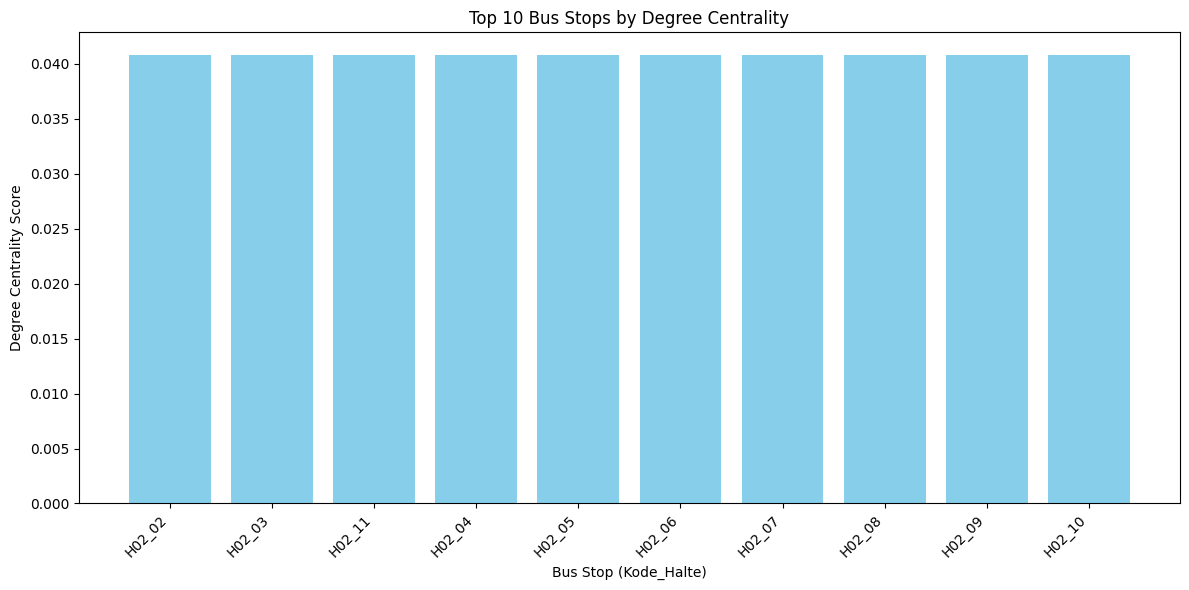

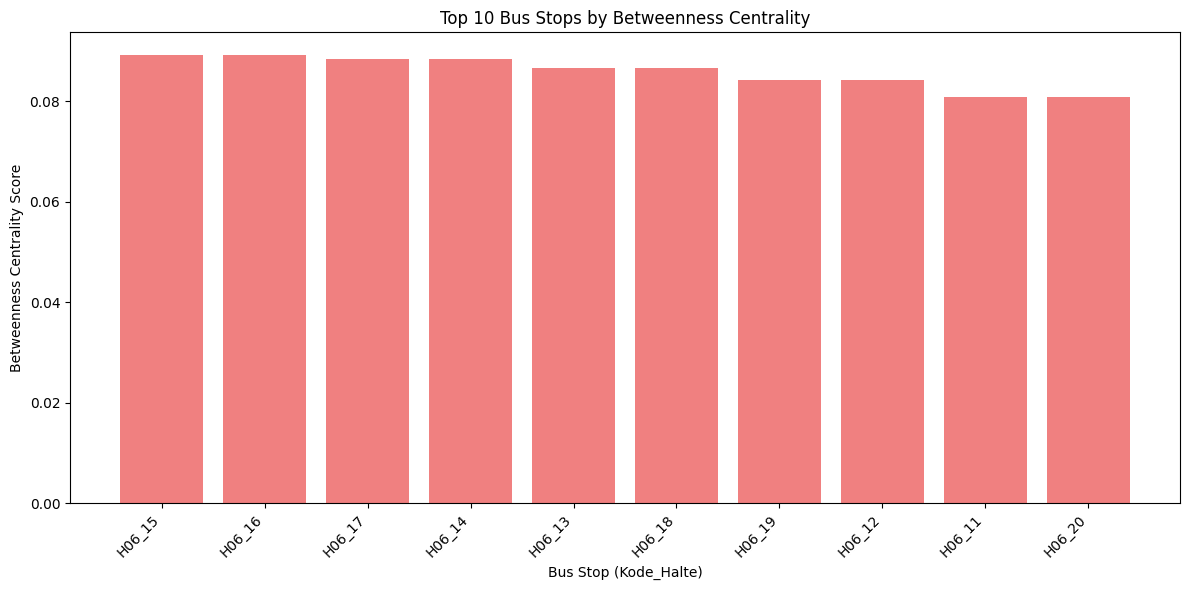

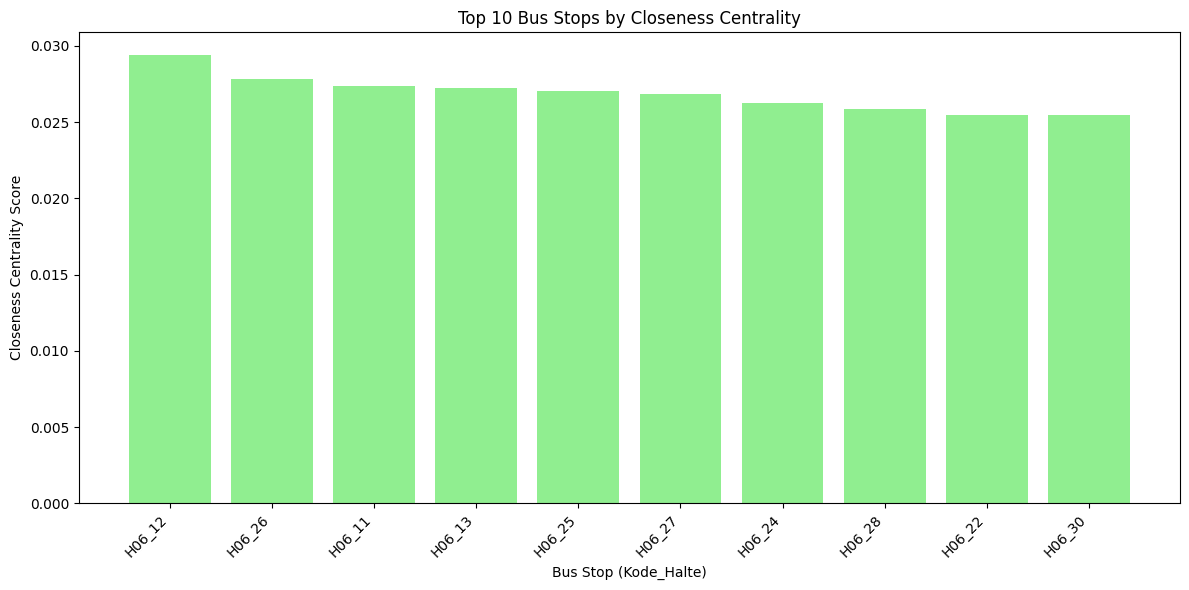

Centrality measure visualizations complete.


In [ ]:
print("Visualizing top 10 bus stops by centrality measures...")

# 1. Degree Centrality
top_10_degree = centrality_df.sort_values(by='Degree_Centrality', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_degree.index, top_10_degree['Degree_Centrality'], color='skyblue')
plt.title('Top 10 Bus Stops by Degree Centrality')
plt.xlabel('Bus Stop (Kode_Halte)')
plt.ylabel('Degree Centrality Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Betweenness Centrality
top_10_betweenness = centrality_df.sort_values(by='Betweenness_Centrality', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_betweenness.index, top_10_betweenness['Betweenness_Centrality'], color='lightcoral')
plt.title('Top 10 Bus Stops by Betweenness Centrality')
plt.xlabel('Bus Stop (Kode_Halte)')
plt.ylabel('Betweenness Centrality Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Closeness Centrality
top_10_closeness = centrality_df.sort_values(by='Closeness_Centrality', ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_closeness.index, top_10_closeness['Closeness_Centrality'], color='lightgreen')
plt.title('Top 10 Bus Stops by Closeness Centrality')
plt.xlabel('Bus Stop (Kode_Halte)')
plt.ylabel('Closeness Centrality Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Centrality measure visualizations complete.")

In [ ]:
import folium

# Re-calculate the average latitude and longitude for map centering
center_lat = all_haltestops['Latitude'].mean()
center_lon = all_haltestops['Longitude'].mean()

# Create a new folium map object
bus_map_centrality = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Define a color scheme for different corridors (reusing from previous map)
corridor_colors = {
    2: 'blue',
    6: 'red'
}

# Add all bus stop markers to the map (base layer)
for index, row in all_haltestops.iterrows():
    koridor_color = corridor_colors.get(row['Koridor'], 'gray') # Default to gray
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=koridor_color,
        fill=True,
        fill_color=koridor_color,
        fill_opacity=0.5,
        popup=f"<b>Halte:</b> {row['Nama_Halte']}<br><b>Koridor:</b> {row['Koridor']}"
    ).add_to(bus_map_centrality)

# Add all routes (polylines) to the map (base layer)
halte_coords_dict = all_haltestops.set_index('Kode_Halte')[['Latitude', 'Longitude']].to_dict('index')

for index, row in all_routes.iterrows():
    from_halte_code = row['From_Halte']
    to_halte_code = row['To_Halte']
    koridor_id = row['Koridor']

    if from_halte_code in halte_coords_dict and to_halte_code in halte_coords_dict:
        from_lat = halte_coords_dict[from_halte_code]['Latitude']
        from_lon = halte_coords_dict[from_halte_code]['Longitude']
        to_lat = halte_coords_dict[to_halte_code]['Latitude']
        to_lon = halte_coords_dict[to_halte_code]['Longitude']

        route_color = corridor_colors.get(koridor_id, 'black') # Default to black

        folium.PolyLine(
            locations=[[from_lat, from_lon], [to_lat, to_lon]],
            color=route_color,
            weight=2,
            opacity=0.5
        ).add_to(bus_map_centrality)

print("Overlaying centrality measures...")

# Function to add centrality markers with distinct styling
def add_centrality_markers(map_object, centrality_df_subset, color, centrality_type):
    for halte_code, row in centrality_df_subset.iterrows():
        halte_info = all_haltestops[all_haltestops['Kode_Halte'] == halte_code].iloc[0]
        folium.CircleMarker(
            location=[halte_info['Latitude'], halte_info['Longitude']],
            radius=8,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.8,
            popup=f"<b>Halte:</b> {halte_info['Nama_Halte']}<br><b>Koridor:</b> {halte_info['Koridor']}<br><b>{centrality_type}:</b> {row[centrality_type]:.4f}"
        ).add_to(map_object)

# 1. Degree Centrality (Top 10)
top_10_degree = centrality_df.sort_values(by='Degree_Centrality', ascending=False).head(10)
add_centrality_markers(bus_map_centrality, top_10_degree, 'purple', 'Degree_Centrality')

# 2. Betweenness Centrality (Top 10)
top_10_betweenness = centrality_df.sort_values(by='Betweenness_Centrality', ascending=False).head(10)
add_centrality_markers(bus_map_centrality, top_10_betweenness, 'orange', 'Betweenness_Centrality')

# 3. Closeness Centrality (Top 10)
top_10_closeness = centrality_df.sort_values(by='Closeness_Centrality', ascending=False).head(10)
add_centrality_markers(bus_map_centrality, top_10_closeness, 'darkgreen', 'Closeness_Centrality')

print("Interactive map with centrality highlights created.")

# Display the map
bus_map_centrality

Overlaying centrality measures...
Interactive map with centrality highlights created.
